# 01 - Composite plate FEM reference with Monte Carlo

This notebook builds the Monte Carlo FEM reference for the composite plate with random stiffness fields.
It provides clean chapter-ready figures and data for the PINN-PC notebook.

In [1]:
import time
from pathlib import Path

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.interpolate import RegularGridInterpolator
from tqdm import tqdm

from phd.plot import get_current_config as plt_cfg, book_config, KUL_CYCLE

book_config.set_as_current()
page_width = plt_cfg().page_width
mpl.rcParams["axes.prop_cycle"] = mpl.cycler(color=KUL_CYCLE)
mpl.rcParams["image.cmap"] = "viridis"

save_fig = True
if save_fig:
    mpl.rcParams["pgf.texsystem"] = "pdflatex"

def find_project_root(start: Path) -> Path:
    current = start.resolve()
    for parent in [current, *current.parents]:
        if (parent / "pyproject.toml").exists():
            return parent
    raise FileNotFoundError("Could not find project root (missing pyproject.toml).")

PROJECT_ROOT = find_project_root(Path.cwd())
CHAPTER_DIR = PROJECT_ROOT / "chapters" / "V_UncertaintyPropagation" / "02_composite_plate"
IMAGE_DIR = CHAPTER_DIR / "images"
PGF_DIR = IMAGE_DIR / "pgf"
PDF_DIR = IMAGE_DIR / "pdf"
PNG_DIR = IMAGE_DIR / "png"
DATA_DIR = CHAPTER_DIR / "data"

for d in [PGF_DIR, PDF_DIR, PNG_DIR, DATA_DIR]:
    d.mkdir(parents=True, exist_ok=True)

def save_figure(fig, name: str, dpi: int = 300, vector_format: str = "pgf"):
    if not save_fig:
        return
    if vector_format == "pgf":
        fig.savefig(PGF_DIR / f"{name}.pgf", bbox_inches="tight")
    elif vector_format == "pdf":
        fig.savefig(PDF_DIR / f"{name}.pdf", bbox_inches="tight")
    fig.savefig(PNG_DIR / f"{name}.png", bbox_inches="tight", dpi=dpi)

print(f"Project root: {PROJECT_ROOT}")
print(f"Chapter dir: {CHAPTER_DIR}")

Project root: /home/r2d2/code/PhD
Chapter dir: /home/r2d2/code/PhD/chapters/V_UncertaintyPropagation/02_composite_plate


## Problem and random-field setup

In [2]:
SEED = 42
np.random.seed(SEED)

L_PLATE = 100.0
P_STRESS = 0.1

# Parameters from Section 5.3 (underlying Gaussian fields for lognormal mapping).
C11_PARAM = {"mu": 1.55, "sigma": 0.129, "lx": 75.0, "ly": 100.0}
C33_PARAM = {"mu": 0.316, "sigma": 0.027, "lx": 100.0, "ly": 75.0}

N_GRID = 100
x_grid = np.linspace(0.0, L_PLATE, N_GRID)
y_grid = np.linspace(0.0, L_PLATE, N_GRID)
Xg, Yg = np.meshgrid(x_grid, y_grid, indexing="ij")

def sqexp_cov_1d(x: np.ndarray, corr_len: float) -> np.ndarray:
    r2 = (x[:, None] - x[None, :]) ** 2
    return np.exp(-r2 / (corr_len**2))

def separable_kl_2d(x: np.ndarray, y: np.ndarray, lx: float, ly: float):
    kx = sqexp_cov_1d(x, lx)
    ky = sqexp_cov_1d(y, ly)
    eval_x, evec_x = np.linalg.eigh(kx)
    eval_y, evec_y = np.linalg.eigh(ky)

    idx_x = eval_x.argsort()[::-1]
    idx_y = eval_y.argsort()[::-1]
    eval_x, evec_x = eval_x[idx_x], evec_x[:, idx_x]
    eval_y, evec_y = eval_y[idx_y], evec_y[:, idx_y]

    eval_2d = np.outer(eval_x, eval_y).ravel()
    order = np.argsort(eval_2d)[::-1]

    # Store index pairs so we can evaluate 2D modes on demand without building giant matrices.
    ix, iy = np.unravel_index(order, (len(eval_x), len(eval_y)))
    return eval_x, evec_x, eval_y, evec_y, eval_2d[order], np.stack([ix, iy], axis=1)

def explained_variance_ratio(lam_sorted: np.ndarray) -> np.ndarray:
    total = np.sum(lam_sorted)
    return np.cumsum(lam_sorted) / total

def build_mode_tensor(evec_x: np.ndarray, evec_y: np.ndarray, pairs: np.ndarray, n_modes: int) -> np.ndarray:
    modes = np.zeros((evec_x.shape[0], evec_y.shape[0], n_modes))
    for m in range(n_modes):
        i, j = pairs[m]
        modes[:, :, m] = np.outer(evec_x[:, i], evec_y[:, j])
    return modes

evalx_11, evecx_11, evaly_11, evecy_11, eval2d_11, pairs_11 = separable_kl_2d(x_grid, y_grid, C11_PARAM["lx"], C11_PARAM["ly"])
evalx_33, evecx_33, evaly_33, evecy_33, eval2d_33, pairs_33 = separable_kl_2d(x_grid, y_grid, C33_PARAM["lx"], C33_PARAM["ly"])

expl_11 = explained_variance_ratio(eval2d_11)
threshold = 0.95
M_FIELD = int(np.argmax(expl_11 >= threshold) + 1)
print(f"95% variance for C11 retained with M = {M_FIELD}")

# Use 4 modes per field to match chapter setup.
M_FIELD = 4

phi11 = build_mode_tensor(evecx_11, evecy_11, pairs_11, M_FIELD)
phi33 = build_mode_tensor(evecx_33, evecy_33, pairs_33, M_FIELD)
lam11 = eval2d_11[:M_FIELD]
lam33 = eval2d_33[:M_FIELD]

95% variance for C11 retained with M = 4


<>:5: SyntaxWarning: invalid escape sequence '\%'
<>:5: SyntaxWarning: invalid escape sequence '\%'
/tmp/ipykernel_397315/1539324586.py:5: SyntaxWarning: invalid escape sequence '\%'
  ax_var.set_ylabel("Explained variance (\%)")


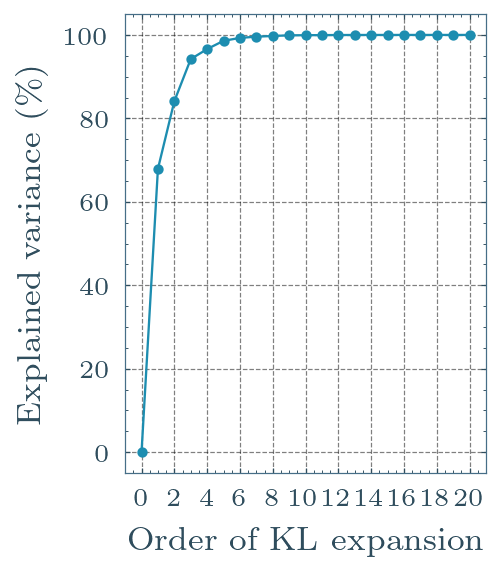

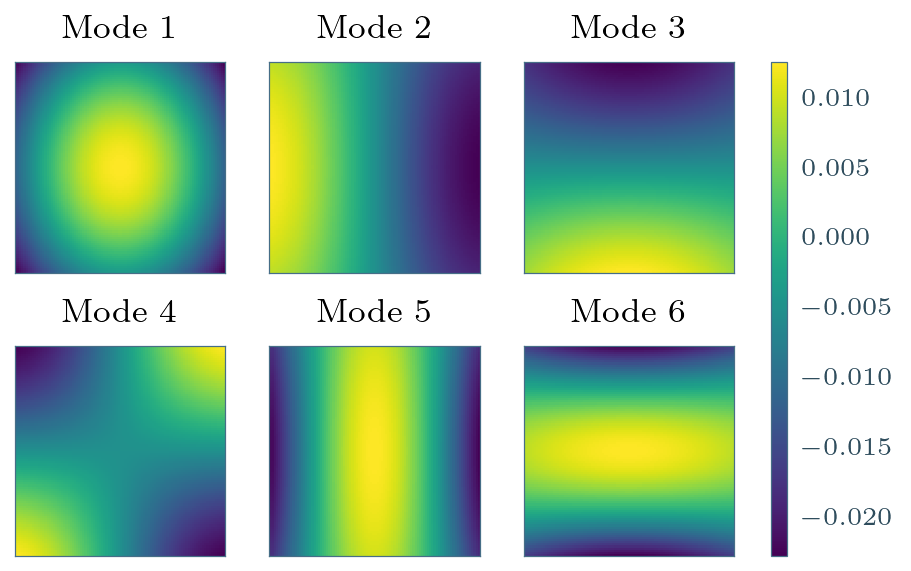

In [3]:
fig_var, ax_var = plt.subplots(figsize=(0.35 * page_width, 0.4 * page_width), dpi=300, constrained_layout=True)
n_plot = 20
ax_var.plot(np.arange(0, n_plot + 1), [0.0] + list(100.0 * expl_11[:n_plot]), marker="o", markersize=plt_cfg().scale * 4)
ax_var.set_xlabel("Order of KL expansion")
ax_var.set_ylabel("Explained variance (\%)")
ax_var.set_xticks(np.arange(0, n_plot + 1, 2))
save_figure(fig_var, "KL_expansion_C11_variance")
plt.show()

fig_modes, axs = plt.subplots(2, 3, figsize=(0.65 * page_width, 0.4 * page_width), dpi=300, constrained_layout=True, gridspec_kw={"wspace": 0.1})
for i, ax in enumerate(axs.flat):
    mode_i = build_mode_tensor(evecx_11, evecy_11, pairs_11, i + 1)[:, :, i]
    im = ax.pcolormesh(Xg, Yg, mode_i, shading="auto")
    ax.set_title(f"Mode {i + 1}")
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
fig_modes.colorbar(im, ax=axs.ravel().tolist(), fraction=0.03, aspect=30)
save_figure(fig_modes, "KL_expansion_C11", vector_format="pdf")
plt.show()

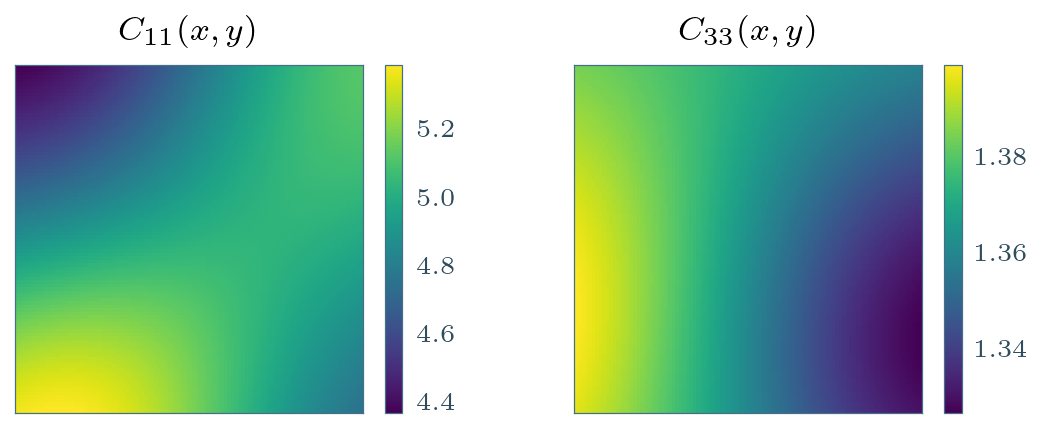

In [4]:
def sample_lognormal_field(xi: np.ndarray, phi: np.ndarray, lam: np.ndarray, param: dict) -> np.ndarray:
    gauss_part = np.tensordot(phi * np.sqrt(lam)[None, None, :], xi, axes=([2], [0]))
    return np.exp(param["mu"] + param["sigma"] * gauss_part)

xi11_1 = np.random.randn(M_FIELD)
xi33_1 = np.random.randn(M_FIELD)
C11_1 = sample_lognormal_field(xi11_1, phi11, lam11, C11_PARAM)
C33_1 = sample_lognormal_field(xi33_1, phi33, lam33, C33_PARAM)

fig_rf, ax_rf = plt.subplots(1, 2, figsize=(0.8 * page_width, 0.3 * page_width), dpi=300, constrained_layout=True)
im0 = ax_rf[0].pcolormesh(Xg, Yg, C11_1, shading="auto")
ax_rf[0].set_title(r"$C_{11}(x,y)$")
ax_rf[0].set_aspect("equal")
ax_rf[0].set_xticks([])
ax_rf[0].set_yticks([])
fig_rf.colorbar(im0, ax=ax_rf[0])
im1 = ax_rf[1].pcolormesh(Xg, Yg, C33_1, shading="auto")
ax_rf[1].set_title(r"$C_{33}(x,y)$")
ax_rf[1].set_aspect("equal")
ax_rf[1].set_xticks([])
ax_rf[1].set_yticks([])
fig_rf.colorbar(im1, ax=ax_rf[1])
save_figure(fig_rf, "C11_C33_sample", vector_format="pdf")
plt.show()

## FEM model and Monte Carlo simulations

In [5]:
# FEniCS import compatible with common installs.
try:
    from dolfin import (
        RectangleMesh,
        Point,
        Constant,
        FunctionSpace,
        VectorFunctionSpace,
        TensorFunctionSpace,
        Function,
        TrialFunction,
        TestFunction,
        DirichletBC,
        AutoSubDomain,
        MeshFunction,
        Measure,
        SpatialCoordinate,
        Identity,
        nabla_grad,
        div,
        inner,
        dot,
        dx,
        solve,
        project,
        set_log_level,
        LogLevel,
    )
except Exception:
    from fenics import (
        RectangleMesh,
        Point,
        Constant,
        FunctionSpace,
        VectorFunctionSpace,
        TensorFunctionSpace,
        Function,
        TrialFunction,
        TestFunction,
        DirichletBC,
        AutoSubDomain,
        MeshFunction,
        Measure,
        SpatialCoordinate,
        Identity,
        nabla_grad,
        div,
        inner,
        dot,
        dx,
        solve,
        project,
        set_log_level,
        LogLevel,
    )

def solve_plate_fem(c11_field: np.ndarray, c33_field: np.ndarray, mesh_n: int = 80):
    lmbd_field = c11_field - 2.0 * c33_field
    mu_field = c33_field

    L = Constant(L_PLATE)
    mesh = RectangleMesh(Point(0.0, 0.0), Point(L_PLATE, L_PLATE), mesh_n, mesh_n)

    V_scalar = FunctionSpace(mesh, "P", 1)
    V_vec = VectorFunctionSpace(mesh, "P", 1)

    coords = V_scalar.tabulate_dof_coordinates().reshape((-1, 2))
    interp_lmbd = RegularGridInterpolator((x_grid, y_grid), lmbd_field)
    interp_mu = RegularGridInterpolator((x_grid, y_grid), mu_field)

    lmbd_fun = Function(V_scalar)
    mu_fun = Function(V_scalar)
    lmbd_fun.vector()[:] = interp_lmbd(coords)
    mu_fun.vector()[:] = interp_mu(coords)

    tol = 1e-12

    def left_boundary(x, on_boundary):
        return on_boundary and abs(x[0]) < tol

    def bottom_boundary(x, on_boundary):
        return on_boundary and abs(x[1]) < tol

    def right_boundary(x, on_boundary):
        return on_boundary and abs(x[0] - float(L_PLATE)) < tol

    bc = [
        DirichletBC(V_vec.sub(0), Constant(0.0), left_boundary),
        DirichletBC(V_vec.sub(1), Constant(0.0), bottom_boundary),
    ]

    right = AutoSubDomain(right_boundary)
    boundaries = MeshFunction("size_t", mesh, mesh.topology().dim() - 1)
    boundaries.set_all(0)
    right.mark(boundaries, 1)
    ds = Measure("ds", domain=mesh, subdomain_data=boundaries)

    def eps(u):
        return 0.5 * (nabla_grad(u) + nabla_grad(u).T)

    def sig(u):
        d = u.geometric_dimension()
        return lmbd_fun * div(u) * Identity(d) + 2.0 * mu_fun * eps(u)

    u = TrialFunction(V_vec)
    v = TestFunction(V_vec)
    f = Constant((0.0, 0.0))
    traction = Constant((P_STRESS, 0.0))

    a = inner(sig(u), eps(v)) * dx
    Lform = dot(f, v) * dx + dot(traction, v) * ds(1)

    u_sol = Function(V_vec)
    solve(a == Lform, u_sol, bc)

    uv = u_sol.compute_vertex_values(mesh).reshape((2, -1)).T
    xy = mesh.coordinates().copy()
    return xy, uv

set_log_level(LogLevel.ERROR)

In [7]:
N_MC = 10
M_TOTAL = 2 * M_FIELD

xi11_mc = np.random.randn(N_MC, M_FIELD)
xi33_mc = np.random.randn(N_MC, M_FIELD)
xi_all_mc = np.hstack([xi11_mc, xi33_mc])

u_samples = []
xy_ref = None

start = time.time()
for i in tqdm(range(N_MC), desc="FEM Monte Carlo"):
    c11_i = sample_lognormal_field(xi11_mc[i], phi11, lam11, C11_PARAM)
    c33_i = sample_lognormal_field(xi33_mc[i], phi33, lam33, C33_PARAM)
    xy_i, u_i = solve_plate_fem(c11_i, c33_i, mesh_n=80)
    if xy_ref is None:
        xy_ref = xy_i
    u_samples.append(u_i)

u_samples = np.stack(u_samples, axis=0)
elapsed = time.time() - start
print(f"Monte Carlo completed in {elapsed/60:.1f} min")

u_mean = np.mean(u_samples, axis=0)
u_std = np.std(u_samples, axis=0)
u_stoch = u_samples - u_mean[None, :, :]

modes_ux = (xi_all_mc.T @ u_stoch[:, :, 0]) / N_MC
modes_uy = (xi_all_mc.T @ u_stoch[:, :, 1]) / N_MC

np.savez(
    DATA_DIR / "mc_reference_plate.npz",
    xy=xy_ref,
    u_samples=u_samples,
    u_mean=u_mean,
    u_std=u_std,
    xi=xi_all_mc,
    modes_ux=modes_ux,
    modes_uy=modes_uy,
    x_grid=x_grid,
    y_grid=y_grid,
    phi11=phi11,
    phi33=phi33,
    lam11=lam11,
    lam33=lam33,
    c11_mu=C11_PARAM["mu"],
    c11_sigma=C11_PARAM["sigma"],
    c33_mu=C33_PARAM["mu"],
    c33_sigma=C33_PARAM["sigma"],
    L=L_PLATE,
    p_stress=P_STRESS,
    M_field=M_FIELD,
    seed=SEED,
)

FEM Monte Carlo: 100%|██████████| 10/10 [00:01<00:00,  5.27it/s]

Monte Carlo completed in 0.0 min


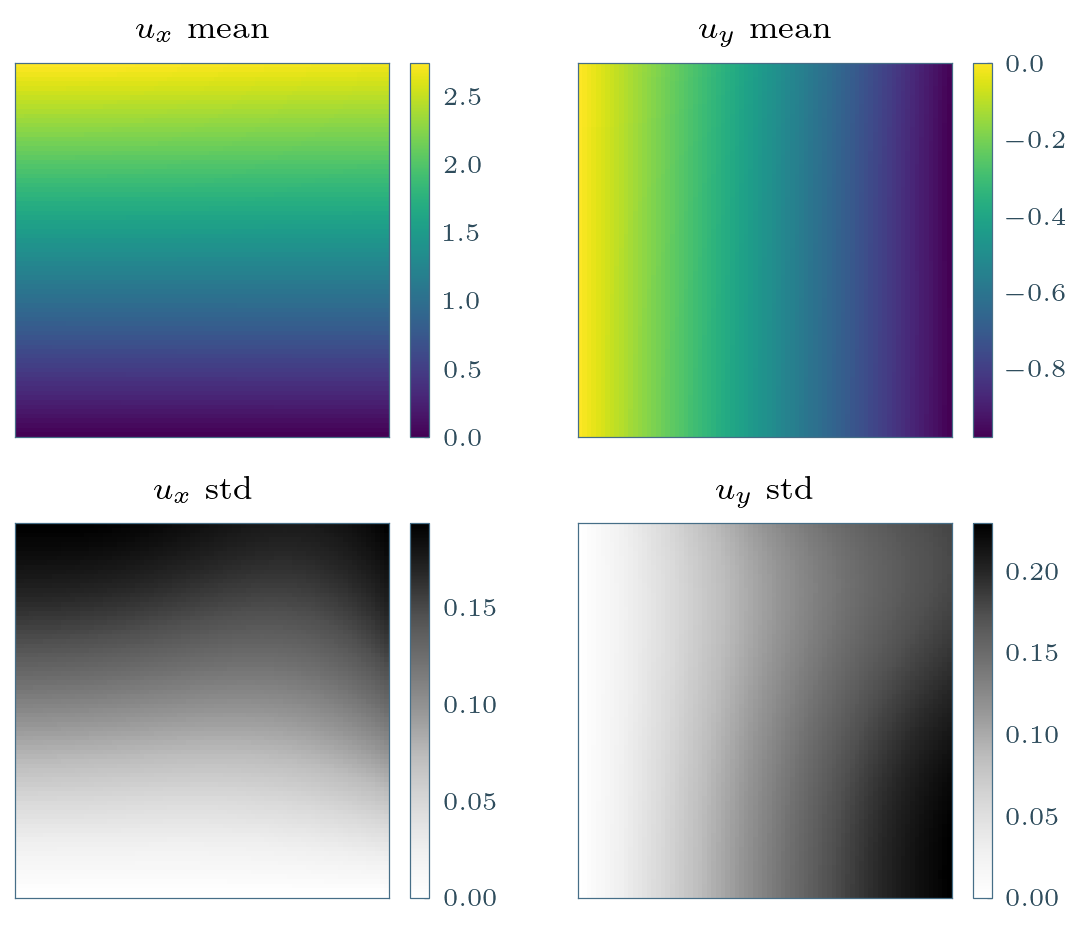

In [9]:
# MC mean/std displacement fields (for Figure V3_MC_displacement).
x_unique = np.unique(xy_ref[:, 0])
y_unique = np.unique(xy_ref[:, 1])
nx, ny = len(x_unique), len(y_unique)

ux_mean = u_mean[:, 0].reshape(nx, ny)
uy_mean = u_mean[:, 1].reshape(nx, ny)
ux_std = u_std[:, 0].reshape(nx, ny)
uy_std = u_std[:, 1].reshape(nx, ny)
Xv, Yv = np.meshgrid(x_unique, y_unique, indexing="ij")

fig_mc, axs = plt.subplots(2, 2, figsize=(0.8 * page_width, 0.65 * page_width), dpi=300, constrained_layout=True)
fields = [ux_mean, uy_mean, ux_std, uy_std]
titles = [r"$u_x$ mean", r"$u_y$ mean", r"$u_x$ std", r"$u_y$ std"]
for ax, field, title in zip(axs.flat, fields, titles):
    color = "viridis" if "mean" in title else "Grays"
    im = ax.pcolormesh(Xv, Yv, field, shading="auto", cmap=color)
    ax.set_title(title)
    ax.set_aspect("equal")
    fig_mc.colorbar(im, ax=ax)
    ax.set_xticks([])
    ax.set_yticks([])
save_figure(fig_mc, "MC_mean_std", vector_format="pdf")
plt.show()